# Basel III Capital Adequacy

**Supervisory stress-test failure analysis for bank capital resilience**

This notebook presents a complete HUG-IML model-governance workflow: data and metadata review, interpretable pattern training, performance assessment, rule inventory, threshold behavior, and subgroup monitoring.

## Review orientation

- Centers on capital-ratio adequacy, liquidity coverage, stable funding, leverage, RWA density, and portfolio concentration.
- Frames HUG-IML patterns as supervisory evidence for challenger-model review and capital policy monitoring.

The objective is not only predictive performance. The workflow emphasizes inspectable decision evidence that can be reviewed by model-risk, audit, compliance, and domain stakeholders.

In [1]:

import os, json, warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, accuracy_score, precision_recall_fscore_support
)
from hugiml import HUGIMLClassifierNative

RANDOM_STATE = 42
DATA_FILE = 'nb07_basel_ca_data.csv'
METADATA_FILE = 'nb07_basel_ca_metadata.csv'
TARGET = 'fails_stress_test'
POSITIVE_LABEL = 'Stress-test failure'
GROUP_COLUMNS = ['bank_size', 'business_model']
MODEL_PARAMS = dict(B=10, L=1, G=5e-4, topK=100)

THEME = {'name': 'Supervisory capital dashboard', 'bg': '#eef4f1', 'panel': '#ffffff', 'text': '#17332d', 'muted': '#5f706d', 'accent': '#006b54', 'accent2': '#c49a24', 'accent3': '#914d3d', 'grid': '#d8e3df'}

plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.facecolor': THEME['panel'],
    'figure.facecolor': THEME['bg'],
    'axes.edgecolor': THEME['grid'],
    'axes.labelcolor': THEME['text'],
    'xtick.color': THEME['muted'],
    'ytick.color': THEME['muted'],
    'text.color': THEME['text'],
    'font.size': 10,
    'axes.titleweight': 'bold'
})

display(HTML("""
<style>
:root {
  --bg: #eef4f1;
  --panel: #ffffff;
  --text: #17332d;
  --muted: #5f706d;
  --accent: #006b54;
  --accent2: #c49a24;
  --accent3: #914d3d;
  --grid: #d8e3df;
}
.jp-Notebook, body { background: var(--bg) !important; color: var(--text); }
h1, h2, h3 { color: var(--text); letter-spacing: -0.02em; }
h1 { border-bottom: 4px solid var(--accent); padding-bottom: 0.35rem; }
h2 { margin-top: 1.6rem; border-left: 6px solid var(--accent2); padding-left: 0.7rem; }
table { border-collapse: collapse; width: 100%; font-size: 0.92rem; }
th { background: var(--accent); color: white; text-align: left; }
td, th { border: 1px solid var(--grid); padding: 0.48rem 0.55rem; }
tr:nth-child(even) { background: rgba(127,127,127,0.06); }
.gov-card-grid { display: grid; grid-template-columns: repeat(4, minmax(0,1fr)); gap: 0.9rem; margin: 0.8rem 0 1.0rem; }
.gov-card { background: var(--panel); border: 1px solid var(--grid); border-radius: 16px; padding: 0.9rem 1rem; box-shadow: 0 7px 22px rgba(0,0,0,0.08); }
.gov-card .label { color: var(--muted); font-size: 0.78rem; text-transform: uppercase; letter-spacing: 0.06em; }
.gov-card .value { color: var(--accent); font-size: 1.55rem; font-weight: 800; margin-top: 0.2rem; }
.gov-card .note { color: var(--muted); font-size: 0.82rem; margin-top: 0.25rem; }
.callout { background: linear-gradient(135deg, var(--panel), rgba(127,127,127,0.06)); border-left: 6px solid var(--accent3); padding: 0.8rem 1rem; border-radius: 12px; margin: 1rem 0; }
.small-note { color: var(--muted); font-size: 0.9rem; }
</style>
"""))


## Dataset and metadata review

In [2]:

df = pd.read_csv(DATA_FILE)
metadata = pd.read_csv(METADATA_FILE)

target_rate = df[TARGET].mean()
n_rows, n_cols = df.shape
feature_count = n_cols - 1
numeric_features = df.drop(columns=[TARGET]).select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in df.drop(columns=[TARGET]).columns if c not in numeric_features]

missing_cells = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

display(HTML(f'''
<div class="gov-card-grid">
  <div class="gov-card"><div class="label">Rows</div><div class="value">{n_rows:,}</div><div class="note">Modeling population</div></div>
  <div class="gov-card"><div class="label">Candidate features</div><div class="value">{feature_count}</div><div class="note">{len(numeric_features)} numeric, {len(categorical_features)} categorical</div></div>
  <div class="gov-card"><div class="label">Positive class rate</div><div class="value">{target_rate:.2%}</div><div class="note">{POSITIVE_LABEL}</div></div>
  <div class="gov-card"><div class="label">Data checks</div><div class="value">{missing_cells}</div><div class="note">Missing cells; {duplicate_rows:,} duplicate rows</div></div>
</div>
'''))

display(Markdown("### Data sample"))
display(df.head(8))
display(Markdown("### Metadata register"))
display(metadata[['column_name','data_type','description','role','importance','notes']].head(20))


### Data sample

,cet1_ratio,tier1_ratio,total_capital_ratio,leverage_ratio,rwa_density,loan_to_deposit_ratio,npl_ratio,concentration_risk,liquidity_coverage_ratio,net_stable_funding_ratio,market_risk_rwa_pct,operational_risk_rwa_pct,total_assets_bn,bank_size,business_model,fails_stress_test
0,11.318103,14.307344,17.915911,7.087940,51.789331,81.332211,3.366153,28.636947,110.079604,107.320632,7.877716,13.741177,0.587510,small,universal,0.0
1,10.089204,10.000000,14.363103,6.306620,64.728613,101.681562,3.052132,19.269372,95.000000,98.000000,12.153431,13.595040,9.699507,small,universal,0.0
2,13.848929,15.926976,17.424643,5.308788,61.114248,73.296103,4.331577,25.809667,123.137695,110.869286,15.338510,7.277259,4.119008,small,commercial,0.0
3,11.125403,12.027241,12.415219,6.114233,54.781823,66.131231,4.177436,19.179629,96.461930,133.590150,7.356575,7.000000,3.893954,small,retail,0.0
4,13.169616,16.180647,12.676859,5.677988,62.149175,69.203042,1.701680,14.883748,129.200774,120.711935,14.706594,13.402382,30.561711,medium,retail,0.0
5,15.217897,16.895256,18.524452,5.868820,61.024775,84.749734,3.096685,34.648056,184.987662,98.031565,8.003963,13.666343,14.702522,medium,universal,0.0
6,10.830266,17.608573,14.517516,5.373500,40.821358,68.290555,0.998906,15.973211,122.369027,114.135876,3.065866,8.371543,121.039768,large,universal,0.0
7,13.293326,17.332364,15.926737,5.703331,69.352031,69.373254,4.842178,8.709954,151.710278,105.615413,12.475166,17.447277,8.966132,small,retail,0.0


### Metadata register

,column_name,data_type,description,role,importance,notes
0,cet1_ratio,numerical,Common Equity Tier 1 ratio (percentage),feature,Critical,Basel III minimum: 4.5% + 2.5% buffer = 7.0%; ...
1,tier1_ratio,numerical,Tier 1 capital ratio (percentage),feature,High,Basel III minimum: 6.0%; includes CET1 + AT1
2,total_capital_ratio,numerical,Total capital ratio (percentage),feature,High,Basel III minimum: 8.0%; includes Tier 1 + Tier 2
3,leverage_ratio,numerical,Leverage ratio (percentage),feature,Critical,Basel III minimum: 3.0%; <4.6% indicates under...
4,rwa_density,numerical,Risk-weighted assets as percentage of total as...,feature,Medium,Higher RWA density indicates riskier asset por...
5,loan_to_deposit_ratio,numerical,Loan-to-deposit ratio (percentage),feature,Medium,Ratios >100% indicate funding pressure
6,npl_ratio,numerical,Non-performing loan ratio (percentage),feature,High,NPL >3% indicates asset quality deterioration;...
7,concentration_risk,numerical,Largest exposure as percentage of total capital,feature,Medium,High concentration (>25%) amplifies specific b...
8,liquidity_coverage_ratio,numerical,LCR: high-quality liquid assets / net cash out...,feature,Critical,Basel III minimum: 100%; <104% indicates liqui...
9,net_stable_funding_ratio,numerical,NSFR: available stable funding / required stab...,feature,High,Basel III minimum: 100%; measures structural f...


## HUG-IML model training and holdout evaluation

In [3]:

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

clf = HUGIMLClassifierNative(**MODEL_PARAMS)
X_enc, y_enc = clf.prepareXy(X, y)

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_enc, y_enc, test_size=0.30, random_state=RANDOM_STATE, stratify=y_enc
)

clf.fit(X_train_enc, y_train_enc)

y_score = clf.predict_proba(X_test_enc)[:, 1]
auc = roc_auc_score(y_test_enc, y_score)
ap = average_precision_score(y_test_enc, y_score)
patterns = clf.feature_importances().copy()
patterns['direction'] = np.where(patterns['coefficient'] >= 0, 'risk-increasing', 'risk-decreasing')
n_patterns = len(patterns)

fpr, tpr, roc_thresholds = roc_curve(y_test_enc, y_score)
precision, recall, pr_thresholds = precision_recall_curve(y_test_enc, y_score)
youden_idx = int(np.argmax(tpr - fpr))
operating_threshold = float(roc_thresholds[youden_idx])
if not np.isfinite(operating_threshold):
    operating_threshold = 0.50

y_pred = (y_score >= operating_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_enc, y_pred).ravel()
precision_op, recall_op, f1_op, _ = precision_recall_fscore_support(y_test_enc, y_pred, average='binary', zero_division=0)
accuracy_op = accuracy_score(y_test_enc, y_pred)

display(HTML(f'''
<div class="gov-card-grid">
  <div class="gov-card"><div class="label">AUC-ROC</div><div class="value">{auc:.3f}</div><div class="note">Rank separation on holdout</div></div>
  <div class="gov-card"><div class="label">Average precision</div><div class="value">{ap:.3f}</div><div class="note">Positive-class concentration</div></div>
  <div class="gov-card"><div class="label">HUG patterns</div><div class="value">{n_patterns}</div><div class="note">Transparent model evidence</div></div>
  <div class="gov-card"><div class="label">Operating threshold</div><div class="value">{operating_threshold:.3f}</div><div class="note">Youden-index threshold</div></div>
</div>
<div class="callout">
<b>Holdout result.</b> At the selected threshold, precision is <b>{precision_op:.2%}</b>, recall is <b>{recall_op:.2%}</b>, and F1 is <b>{f1_op:.3f}</b>. 
The confusion matrix is TP={tp:,}, FP={fp:,}, TN={tn:,}, FN={fn:,}.
</div>
'''))


## Pattern inventory

The highest-magnitude patterns are the strongest transparent contributors to the model score. Positive coefficients increase the estimated probability of the event; negative coefficients reduce it.

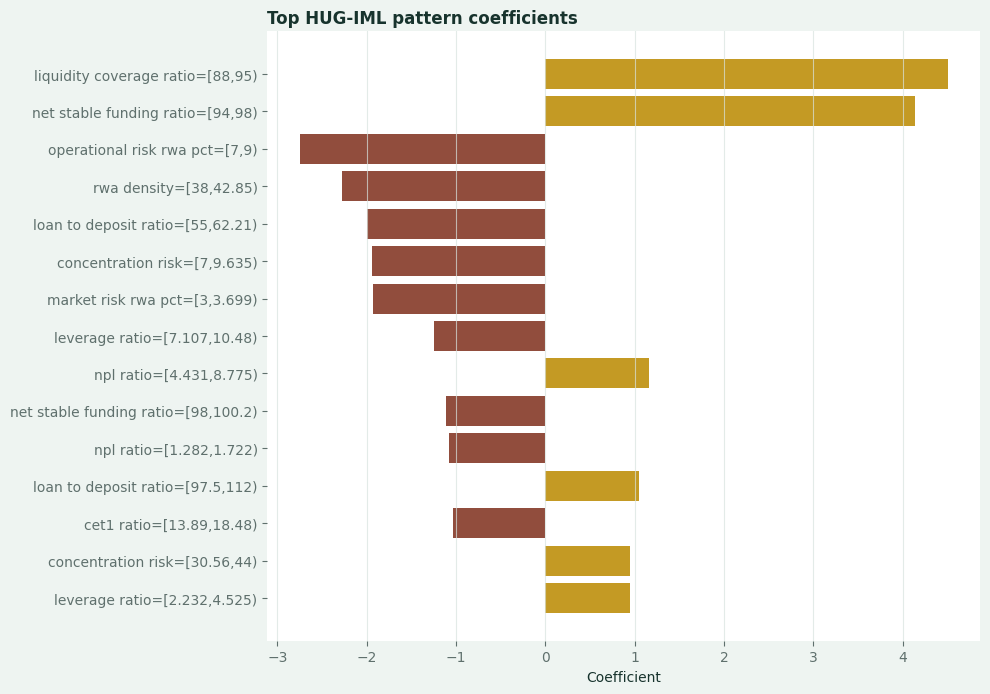

,pattern,coefficient,support,direction
0,"liquidity_coverage_ratio=[88,95)",4.501024,0.0163,risk-increasing
1,"net_stable_funding_ratio=[94,98)",4.135983,0.0189,risk-increasing
2,"operational_risk_rwa_pct=[7,9)",-2.750304,0.1974,risk-decreasing
3,"rwa_density=[38,42.85)",-2.276896,0.1000,risk-decreasing
4,"loan_to_deposit_ratio=[55,62.21)",-1.997720,0.1000,risk-decreasing
5,"concentration_risk=[7,9.635)",-1.937608,0.1000,risk-decreasing
6,"market_risk_rwa_pct=[3,3.699)",-1.935379,0.1000,risk-decreasing
7,"leverage_ratio=[7.107,10.48)",-1.249714,0.1000,risk-decreasing
8,"npl_ratio=[4.431,8.775)",1.160581,0.1000,risk-increasing
9,"net_stable_funding_ratio=[98,100.2)",-1.113570,0.1811,risk-decreasing


### Governance feature register

,column_name,data_type,importance,pattern_count,modeled_signal,notes
0,cet1_ratio,numerical,Critical,6,present in HUG patterns,Basel III minimum: 4.5% + 2.5% buffer = 7.0%; ...
1,leverage_ratio,numerical,Critical,5,present in HUG patterns,Basel III minimum: 3.0%; <4.6% indicates under...
2,liquidity_coverage_ratio,numerical,Critical,3,present in HUG patterns,Basel III minimum: 100%; <104% indicates liqui...
3,total_capital_ratio,numerical,High,7,present in HUG patterns,Basel III minimum: 8.0%; includes Tier 1 + Tier 2
4,npl_ratio,numerical,High,7,present in HUG patterns,NPL >3% indicates asset quality deterioration;...
5,tier1_ratio,numerical,High,6,present in HUG patterns,Basel III minimum: 6.0%; includes CET1 + AT1
6,net_stable_funding_ratio,numerical,High,5,present in HUG patterns,Basel III minimum: 100%; measures structural f...
7,total_assets_bn,numerical,Low,2,present in HUG patterns,Bank size; used to derive bank_size category
8,bank_size,categorical,Low,0,not selected directly,Derived from total_assets_bn; large banks face...
9,business_model,categorical,Low,0,not selected directly,Different models have different risk profiles


In [4]:

def styled_barh(data, x, y, title, xlabel, color_col=None, limit=12):
    plot_df = data.head(limit).copy()
    fig, ax = plt.subplots(figsize=(10, max(4.8, 0.35 * len(plot_df) + 1.8)))
    colors = [THEME['accent2'] if v >= 0 else THEME['accent3'] for v in plot_df[color_col]] if color_col else THEME['accent']
    ax.barh(plot_df[y], plot_df[x], color=colors)
    ax.invert_yaxis()
    ax.set_title(title, loc='left')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', color=THEME['grid'], alpha=0.7)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()

top_patterns = patterns.sort_values('abs_coefficient', ascending=False).head(15).copy()
top_patterns['display_pattern'] = top_patterns['pattern'].str.replace('_', ' ', regex=False)
display(Markdown("## Pattern inventory"))
display(Markdown("The highest-magnitude patterns are the strongest transparent contributors to the model score. Positive coefficients increase the estimated probability of the event; negative coefficients reduce it."))
styled_barh(top_patterns, 'coefficient', 'display_pattern', 'Top HUG-IML pattern coefficients', 'Coefficient', color_col='coefficient', limit=15)
display(top_patterns[['pattern','coefficient','support','direction']].reset_index(drop=True))

# Metadata alignment
feature_rows = metadata[metadata['role'].str.lower().eq('feature')].copy() if 'role' in metadata.columns else metadata.copy()
def feature_in_patterns(feature):
    return int(patterns['pattern'].astype(str).str.startswith(str(feature) + '=').sum() + patterns['pattern'].astype(str).str.startswith(str(feature) + '[').sum())
feature_rows['pattern_count'] = feature_rows['column_name'].map(feature_in_patterns)
feature_rows['modeled_signal'] = np.where(feature_rows['pattern_count'] > 0, 'present in HUG patterns', 'not selected directly')
feature_rows = feature_rows.sort_values(['importance','pattern_count'], ascending=[True, False])
display(Markdown("### Governance feature register"))
display(feature_rows[['column_name','data_type','importance','pattern_count','modeled_signal','notes']].reset_index(drop=True))


## Discrimination and threshold behavior

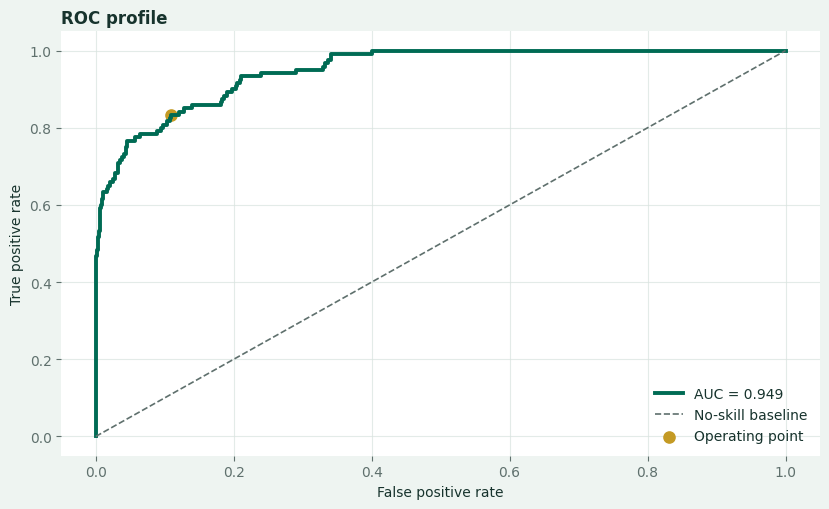

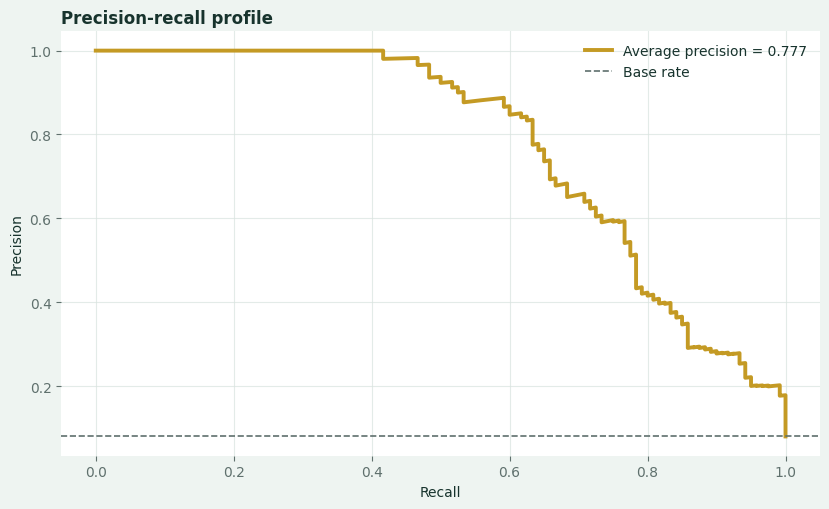

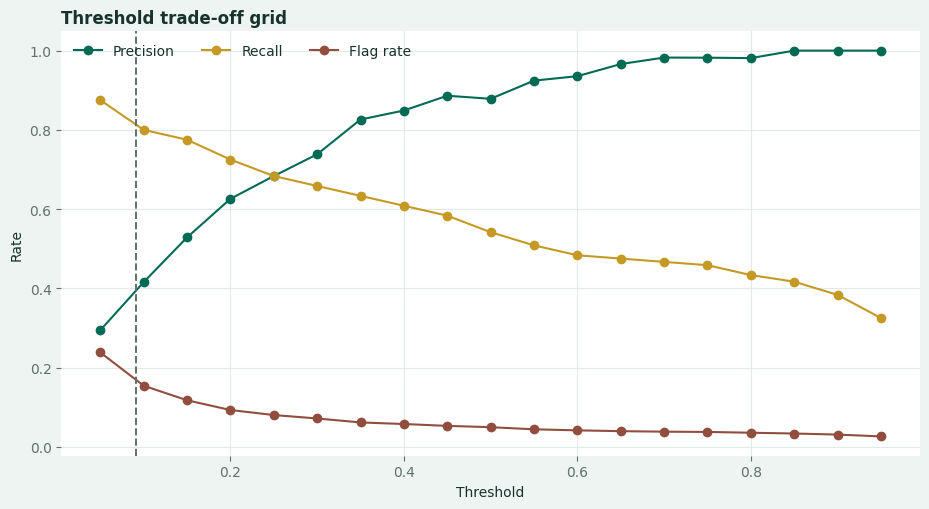

,threshold,precision,recall,f1,flag_rate,false_positive_rate
0,0.05,0.2941,0.8750,0.4403,0.2380,0.1826
1,0.10,0.4156,0.8000,0.5470,0.1540,0.0978
2,0.15,0.5284,0.7750,0.6284,0.1173,0.0601
3,0.20,0.6259,0.7250,0.6718,0.0927,0.0377
4,0.25,0.6833,0.6833,0.6833,0.0800,0.0275
5,0.30,0.7383,0.6583,0.6960,0.0713,0.0203
6,0.35,0.8261,0.6333,0.7170,0.0613,0.0116
7,0.40,0.8488,0.6083,0.7087,0.0573,0.0094
8,0.45,0.8861,0.5833,0.7035,0.0527,0.0065
9,0.50,0.8784,0.5417,0.6701,0.0493,0.0065


In [5]:

display(Markdown("## Discrimination and threshold behavior"))

fig, ax = plt.subplots(figsize=(8.4, 5.2))
ax.plot(fpr, tpr, linewidth=2.8, color=THEME['accent'], label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2, color=THEME['muted'], label='No-skill baseline')
ax.scatter([fpr[youden_idx]], [tpr[youden_idx]], s=65, color=THEME['accent2'], label='Operating point')
ax.set_title('ROC profile', loc='left')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.grid(color=THEME['grid'], alpha=0.7)
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 5.2))
ax.plot(recall, precision, linewidth=2.8, color=THEME['accent2'], label=f'Average precision = {ap:.3f}')
ax.axhline(y_test_enc.mean(), linestyle='--', linewidth=1.2, color=THEME['muted'], label='Base rate')
ax.set_title('Precision-recall profile', loc='left')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.grid(color=THEME['grid'], alpha=0.7)
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

threshold_grid = np.linspace(0.05, 0.95, 19)
threshold_rows = []
for thr in threshold_grid:
    pred = (y_score >= thr).astype(int)
    tn_i, fp_i, fn_i, tp_i = confusion_matrix(y_test_enc, pred).ravel()
    prec_i, rec_i, f1_i, _ = precision_recall_fscore_support(y_test_enc, pred, average='binary', zero_division=0)
    threshold_rows.append({
        'threshold': thr,
        'precision': prec_i,
        'recall': rec_i,
        'f1': f1_i,
        'flag_rate': pred.mean(),
        'false_positive_rate': fp_i / max(fp_i + tn_i, 1)
    })
threshold_table = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(9.4, 5.2))
ax.plot(threshold_table['threshold'], threshold_table['precision'], marker='o', color=THEME['accent'], label='Precision')
ax.plot(threshold_table['threshold'], threshold_table['recall'], marker='o', color=THEME['accent2'], label='Recall')
ax.plot(threshold_table['threshold'], threshold_table['flag_rate'], marker='o', color=THEME['accent3'], label='Flag rate')
ax.axvline(operating_threshold, linestyle='--', linewidth=1.4, color=THEME['muted'])
ax.set_title('Threshold trade-off grid', loc='left')
ax.set_xlabel('Threshold')
ax.set_ylabel('Rate')
ax.grid(color=THEME['grid'], alpha=0.7)
ax.legend(frameon=False, ncol=3)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

display(threshold_table.round(4))


## Subgroup threshold-sensitivity audit

,feature,segment,n,base_rate,flag_rate,auc,precision,recall,false_positive_rate
0,bank_size,medium,576,0.0799,0.1858,0.9345,0.3458,0.8043,0.1321
1,bank_size,small,480,0.0729,0.1354,0.9502,0.4462,0.8286,0.0809
2,bank_size,large,444,0.0878,0.1779,0.9643,0.4304,0.8718,0.1111
3,business_model,retail,624,0.0913,0.1747,0.9442,0.4220,0.8070,0.1111
4,business_model,commercial,543,0.0626,0.1473,0.9396,0.3500,0.8235,0.1022
5,business_model,universal,333,0.0871,0.1862,0.9672,0.4194,0.8966,0.1184


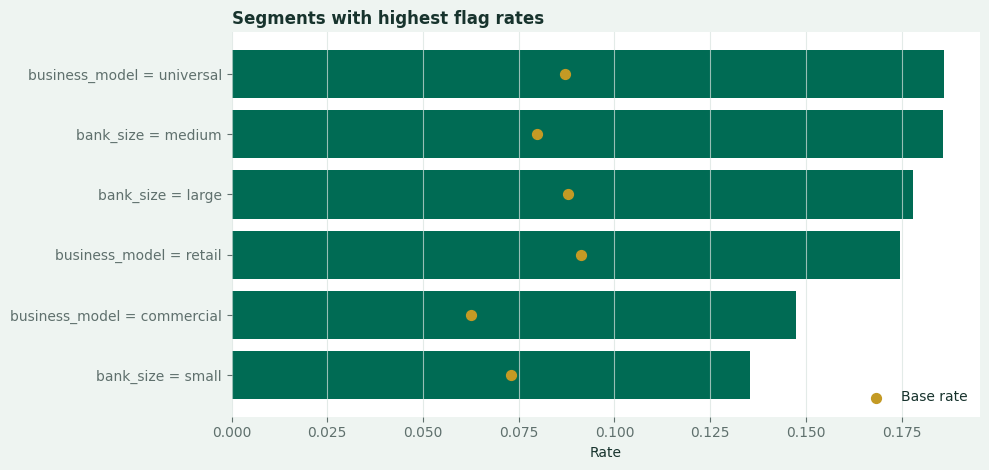

In [6]:

display(Markdown("## Subgroup threshold-sensitivity audit"))

test_index = X_test_enc.index if hasattr(X_test_enc, 'index') else pd.Index(range(len(y_test_enc)))
# Encoded data produced by HUG-IML keeps original columns and index in current library versions.
raw_test = X.loc[test_index].copy()
audit_frame = raw_test.copy()
audit_frame['_actual'] = np.asarray(y_test_enc).astype(int)
audit_frame['_score'] = y_score
audit_frame['_flag'] = (audit_frame['_score'] >= operating_threshold).astype(int)

subgroup_records = []
for col in GROUP_COLUMNS:
    if col not in audit_frame.columns:
        continue
    vc = audit_frame[col].value_counts(dropna=False)
    levels = vc[vc >= max(20, 0.01 * len(audit_frame))].index.tolist()
    for level in levels[:12]:
        g = audit_frame[audit_frame[col].eq(level)]
        if len(g) < 20:
            continue
        y_g = g['_actual'].astype(int).to_numpy()
        flag_g = g['_flag'].astype(int).to_numpy()
        if len(np.unique(y_g)) < 2:
            auc_g = np.nan
        else:
            auc_g = roc_auc_score(y_g, g['_score'])
        tn_g, fp_g, fn_g, tp_g = confusion_matrix(y_g, flag_g, labels=[0,1]).ravel()
        subgroup_records.append({
            'feature': col,
            'segment': str(level),
            'n': len(g),
            'base_rate': y_g.mean(),
            'flag_rate': flag_g.mean(),
            'auc': auc_g,
            'precision': tp_g / max(tp_g + fp_g, 1),
            'recall': tp_g / max(tp_g + fn_g, 1),
            'false_positive_rate': fp_g / max(fp_g + tn_g, 1),
        })

subgroup_audit = pd.DataFrame(subgroup_records)
if len(subgroup_audit):
    display(subgroup_audit.sort_values(['feature','n'], ascending=[True, False]).round(4))
    plot_audit = subgroup_audit.sort_values('flag_rate', ascending=False).head(14).copy()
    plot_audit['segment_label'] = plot_audit['feature'] + ' = ' + plot_audit['segment']
    fig, ax = plt.subplots(figsize=(10, max(4.8, 0.32 * len(plot_audit) + 1.5)))
    ax.barh(plot_audit['segment_label'], plot_audit['flag_rate'], color=THEME['accent'])
    ax.scatter(plot_audit['base_rate'], plot_audit['segment_label'], color=THEME['accent2'], s=50, label='Base rate')
    ax.invert_yaxis()
    ax.set_title('Segments with highest flag rates', loc='left')
    ax.set_xlabel('Rate')
    ax.grid(axis='x', color=THEME['grid'], alpha=0.7)
    ax.legend(frameon=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("No subgroup columns with sufficient holdout support were available for this audit view."))


## Score concentration and review prioritization

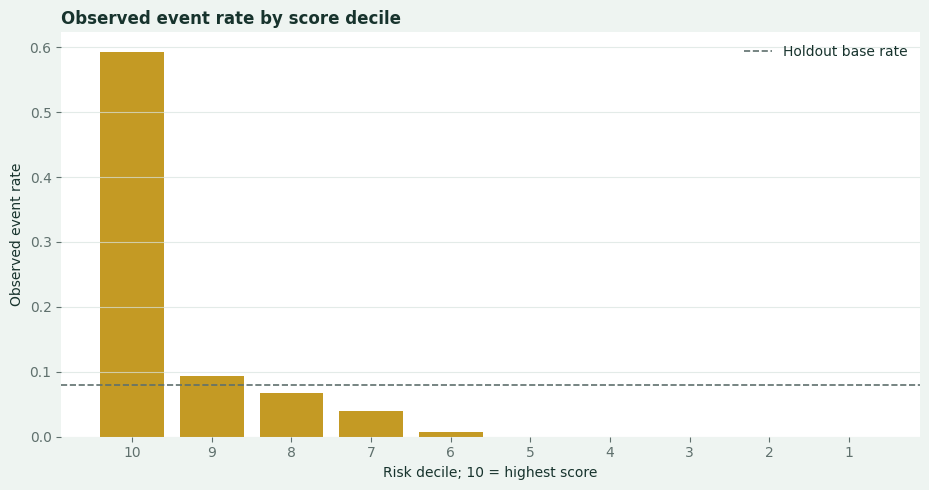

,risk_decile,n,event_rate,avg_score,event_capture,event_capture_share
9,10,150,0.5933,0.5727,89,0.7417
8,9,150,0.0933,0.1128,14,0.1167
7,8,150,0.0667,0.0476,10,0.0833
6,7,150,0.0400,0.0244,6,0.0500
5,6,150,0.0067,0.0131,1,0.0083
4,5,150,0.0000,0.0070,0,0.0000
3,4,150,0.0000,0.0036,0,0.0000
2,3,150,0.0000,0.0017,0,0.0000
1,2,150,0.0000,0.0007,0,0.0000
0,1,150,0.0000,0.0001,0,0.0000


In [7]:

display(Markdown("## Score concentration and review prioritization"))

score_table = pd.DataFrame({'actual': np.asarray(y_test_enc).astype(int), 'score': y_score})
score_table['risk_decile'] = pd.qcut(score_table['score'].rank(method='first'), 10, labels=False) + 1
decile = score_table.groupby('risk_decile').agg(
    n=('actual','size'),
    event_rate=('actual','mean'),
    avg_score=('score','mean'),
    event_capture=('actual','sum')
).reset_index()
decile['event_capture_share'] = decile['event_capture'] / max(decile['event_capture'].sum(), 1)
decile = decile.sort_values('risk_decile', ascending=False)

fig, ax = plt.subplots(figsize=(9.4, 5.0))
ax.bar(decile['risk_decile'].astype(str), decile['event_rate'], color=THEME['accent2'])
ax.axhline(score_table['actual'].mean(), linestyle='--', color=THEME['muted'], linewidth=1.2, label='Holdout base rate')
ax.set_title('Observed event rate by score decile', loc='left')
ax.set_xlabel('Risk decile; 10 = highest score')
ax.set_ylabel('Observed event rate')
ax.grid(axis='y', color=THEME['grid'], alpha=0.7)
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

display(decile.round(4))

top_decile_rate = float(decile.loc[decile['risk_decile'].eq(10), 'event_rate'].iloc[0])
base_rate = float(score_table['actual'].mean())
lift = top_decile_rate / max(base_rate, 1e-12)
display(HTML(f'''
<div class="callout">
<b>Prioritization insight.</b> The highest score decile has an observed event rate of <b>{top_decile_rate:.2%}</b>, 
which is <b>{lift:.1f}×</b> the holdout base rate of <b>{base_rate:.2%}</b>. This supports a queue-based review strategy when operational capacity is limited.
</div>
'''))


In [ ]:

display(Markdown("## Exported governance artifacts"))

artifact_prefix = 'nb07_basel_capital_adequacy'
patterns.to_csv(f'{artifact_prefix}_pattern_inventory.csv', index=False)
threshold_table.to_csv(f'{artifact_prefix}_threshold_grid.csv', index=False)
if 'subgroup_audit' in globals() and len(subgroup_audit):
    subgroup_audit.to_csv(f'{artifact_prefix}_subgroup_audit.csv', index=False)
feature_rows.to_csv(f'{artifact_prefix}_feature_register.csv', index=False)

display(Markdown(f"""
Generated governance artifacts:

- `{artifact_prefix}_pattern_inventory.csv`
- `{artifact_prefix}_threshold_grid.csv`
- `{artifact_prefix}_feature_register.csv`
- `{artifact_prefix}_subgroup_audit.csv` when subgroup audit rows are available
"""))


The completed workflow provides a transparent HUG-IML classifier view for basel iii capital adequacy. The final notebook combines predictive metrics with interpretable pattern evidence, threshold governance, subgroup monitoring, and exportable audit tables.

The strongest governance value comes from the combination of:

- ranked HUG pattern coefficients that can be inspected as decision evidence,
- metadata-aligned feature documentation,
- threshold-specific operating behavior rather than a single static accuracy number,
- subgroup views that highlight where flag rates, recall, or false-positive rates differ materially.